# Calificación Automática de Exámenes de Opción Múltiple
## AVANCE DEL PROYECTO FINAL

**Curso:** Procesamiento Digital de Señales 2  
**Universidad:** Universidad Nacional de Piura  
 
---

## Descripción

Este avance del proyecto es un sistema que califica automáticamente hojas de respuestas de opción múltiple mediante:

1. Detección de **marcadores fiduciales** (cuadros negros) para corregir la perspectiva
2. **Transformada de Hough** para localizar los círculos de respuesta
3. **Conteo de píxeles y momentos** (`cv2.moments`) para determinar cuál opción fue marcada
4. Comparación con clave de respuestas y cálculo de nota vigesimal


## 1. Librerías y funciones auxiliares

Se importan las librerías necesarias y se definen funciones de apoyo para
visualización e inspección de imágenes.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def InfoImg(img):
    print('size:    ', img.shape)
    print('max val: ', np.max(img))
    print('min val: ', np.min(img))
    print('mean val:', round(np.mean(img)))

def mostrar(img, titulo='', cmap=None, figsize=(8,10)):
    plt.figure(figsize=figsize)
    if cmap is None and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(titulo)
    plt.axis('off')
    plt.show()

print('Librerias cargadas correctamente')
print(f'OpenCV version: {cv2.__version__}')


Mounted at /content/drive
Librerias cargadas correctamente
OpenCV version: 4.13.0


## 2. Carga de imagen

Se carga la hoja de respuestas desde Google Drive.  
Modifica `RUTA` con la ruta de tu imagen.


Imagen cargada correctamente
size:     (1650, 1275, 3)
max val:  255
min val:  0
mean val: 236


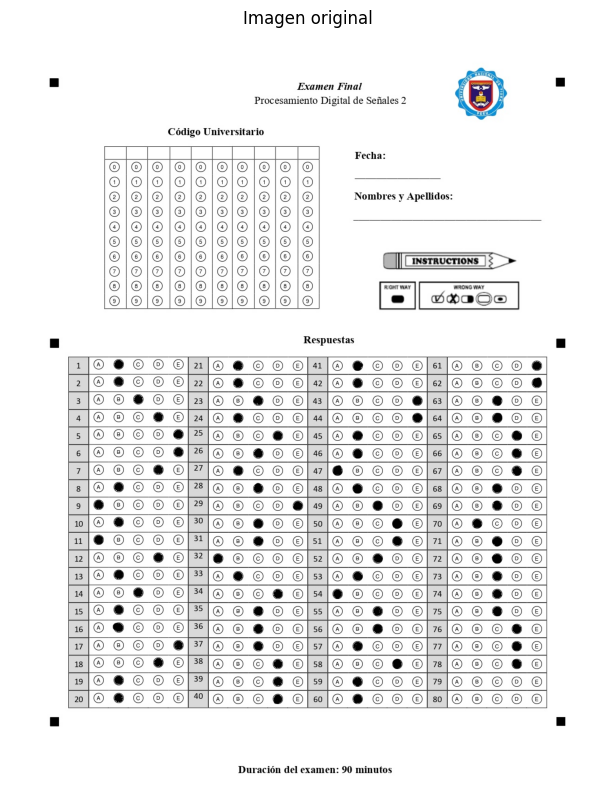

In [2]:
RUTA = '/content/drive/MyDrive/Proyecto_Final/examen3.jpg'

img_original = cv2.imread(RUTA)

if img_original is None:
    print('ERROR: No se encontro la imagen.')
else:
    print('Imagen cargada correctamente')
    InfoImg(img_original)
    mostrar(img_original, 'Imagen original')


## 3. Detección de marcadores y corrección de perspectiva

La hoja tiene **cuadros negros** en las esquinas (marcadores fiduciales).
Se detectan filtrando contornos por:
- **Área** dentro de un rango esperado
- **Aspecto** cuadrado (ancho ≈ alto)
- **Extent** alto (solidez del contorno, descarta letras y círculos)

Con los 4 marcadores se aplica `cv2.getPerspectiveTransform` +
`cv2.warpPerspective` para enderezar la imagen sin importar el ángulo de la foto.


Marcadores detectados: 6
  x=1180, y=108, lado=19.0
  x=94, y=108, lado=19.0
  x=1180, y=667, lado=19.5
  x=96, y=667, lado=19.5
  x=1180, y=1478, lado=19.0
  x=96, y=1478, lado=19.5
Filas agrupadas: 3


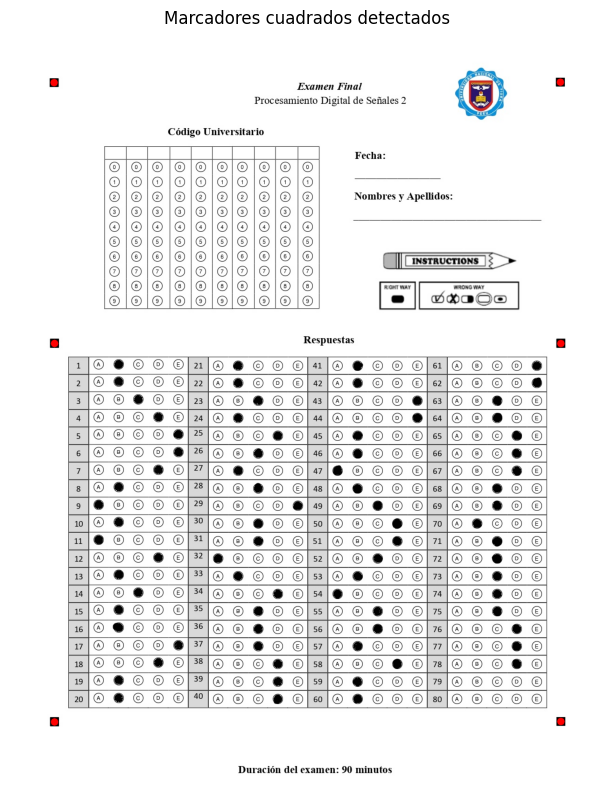

In [3]:
def detectar_marcadores_cuadrados(image, area_min=150, area_max=3000, tol_aspecto=0.2, extent_min=0.85):
    """
    Detecta los cuadros negros (marcadores fiduciales) de la hoja.
    Filtra por area, aspecto cuadrado Y extent (solidez) para descartar letras/circulos.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binaria = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)

    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    marcadores = []
    for c in contornos:
        area = cv2.contourArea(c)
        if area < area_min or area > area_max:
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspecto = w / float(h)
        if abs(aspecto - 1.0) > tol_aspecto:
            continue

        area_rect = w * h
        extent = area / float(area_rect) if area_rect > 0 else 0
        if extent < extent_min:
            continue  # descarta formas no solidas (letras, circulos parciales, etc.)

        cx, cy = x + w / 2, y + h / 2
        marcadores.append((cx, cy, (w + h) / 2))

    marcadores.sort(key=lambda m: m[1])
    return marcadores


def agrupar_marcadores_por_filas(marcadores, dist_y_max=25):
    filas = []
    fila_actual = []
    y_prev = None
    for m in marcadores:
        if y_prev is not None and abs(m[1] - y_prev) > dist_y_max:
            filas.append(fila_actual)
            fila_actual = []
        fila_actual.append(m)
        y_prev = m[1]
    if fila_actual:
        filas.append(fila_actual)
    return filas


marcadores = detectar_marcadores_cuadrados(img_original)
print(f'Marcadores detectados: {len(marcadores)}')
for m in marcadores:
    print(f'  x={m[0]:.0f}, y={m[1]:.0f}, lado={m[2]:.1f}')

filas_marcadores = agrupar_marcadores_por_filas(marcadores)
print(f'Filas agrupadas: {len(filas_marcadores)}')

vis = img_original.copy()
for (cx, cy, lado) in marcadores:
    cv2.circle(vis, (int(cx), int(cy)), 8, (0, 0, 255), -1)
mostrar(vis, 'Marcadores cuadrados detectados')


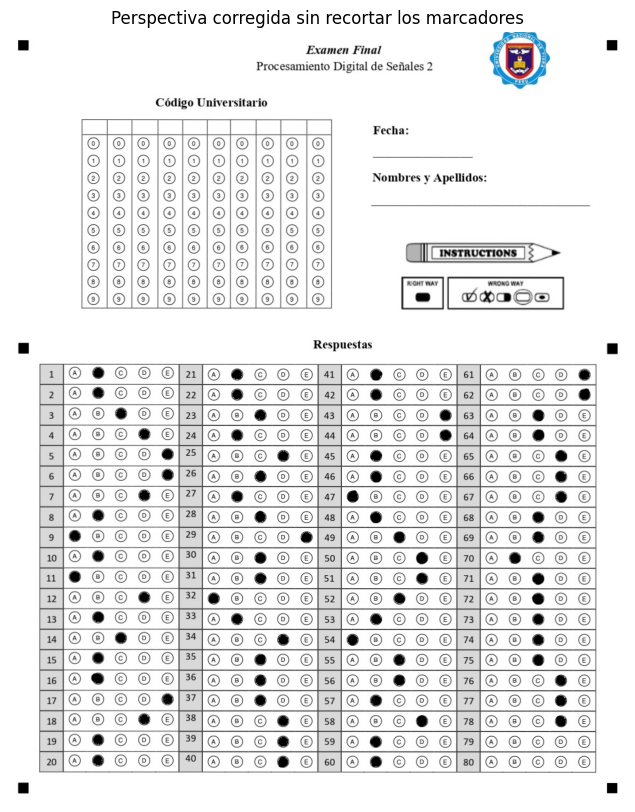

In [4]:
def ordenar_puntos(pts):
    """Ordena 4 puntos como: top-left, top-right, bottom-right, bottom-left"""
    pts = np.array(pts, dtype='float32')
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect


def aplicar_warp_con_margen(image, fila_arriba, fila_abajo, margen_extra=15):
    """
    Usa los 4 marcadores externos (2 de arriba, 2 de abajo) como referencia,
    pero EXPANDE cada punto hacia afuera (segun el lado del marcador + margen_extra)
    para que el cuadradito completo quede dentro del area transformada, sin recortarse.
    """
    arr_arriba = sorted(fila_arriba, key=lambda m: m[0])
    arr_abajo = sorted(fila_abajo, key=lambda m: m[0])

    izq_arriba, der_arriba = arr_arriba[0], arr_arriba[-1]
    izq_abajo, der_abajo = arr_abajo[0], arr_abajo[-1]

    def expandir(m, dx, dy):
        cx, cy, lado = m
        radio = lado / 2 + margen_extra
        return (cx + dx * radio, cy + dy * radio)

    tl = expandir(izq_arriba, -1, -1)
    tr = expandir(der_arriba, +1, -1)
    bl = expandir(izq_abajo, -1, +1)
    br = expandir(der_abajo, +1, +1)

    pts_origen = [tl, tr, bl, br]
    rect = ordenar_puntos(pts_origen)
    (tl, tr, br, bl) = rect

    ancho_a = np.linalg.norm(br - bl)
    ancho_b = np.linalg.norm(tr - tl)
    ancho_max = int(max(ancho_a, ancho_b))

    alto_a = np.linalg.norm(tr - br)
    alto_b = np.linalg.norm(tl - bl)
    alto_max = int(max(alto_a, alto_b))

    destino = np.array([
        [0, 0],
        [ancho_max - 1, 0],
        [ancho_max - 1, alto_max - 1],
        [0, alto_max - 1]], dtype='float32')

    M = cv2.getPerspectiveTransform(rect, destino)
    warp = cv2.warpPerspective(image, M, (ancho_max, alto_max))
    return warp


fila_arriba = filas_marcadores[0]
fila_abajo = filas_marcadores[-1]

img_corregida = aplicar_warp_con_margen(img_original, fila_arriba, fila_abajo, margen_extra=15)
mostrar(img_corregida, 'Perspectiva corregida sin recortar los marcadores')


In [5]:
marcadores = detectar_marcadores_cuadrados(img_original)
print(f'Marcadores detectados: {len(marcadores)}')
for m in marcadores:
    print(f'  x={m[0]:.0f}, y={m[1]:.0f}, lado={m[2]:.1f}')

filas_marcadores = agrupar_marcadores_por_filas(marcadores)
print(f'Filas agrupadas: {len(filas_marcadores)}')
for i, fila in enumerate(filas_marcadores):
    print(f'  Fila {i}: {len(fila)} marcador(es)')


Marcadores detectados: 6
  x=1180, y=108, lado=19.0
  x=94, y=108, lado=19.0
  x=1180, y=667, lado=19.5
  x=96, y=667, lado=19.5
  x=1180, y=1478, lado=19.0
  x=96, y=1478, lado=19.5
Filas agrupadas: 3
  Fila 0: 2 marcador(es)
  Fila 1: 2 marcador(es)
  Fila 2: 2 marcador(es)


Marcadores detectados en img_corregida: 6
  x=1108, y=24, lado=19.0
  x=24, y=24, lado=19.0
  x=25, y=583, lado=19.0
  x=1109, y=584, lado=18.5
  x=1108, y=1394, lado=19.0
  x=24, y=1394, lado=19.0
Filas agrupadas: 3
  Fila 0: 2 marcador(es)
  Fila 1: 2 marcador(es)
  Fila 2: 2 marcador(es)


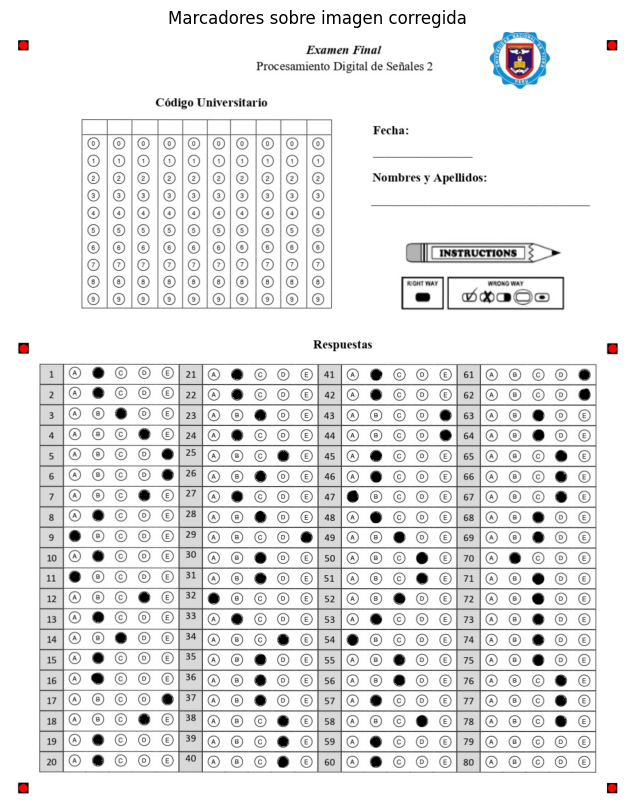

In [6]:
marcadores_corr = detectar_marcadores_cuadrados(img_corregida)
print(f'Marcadores detectados en img_corregida: {len(marcadores_corr)}')
for m in marcadores_corr:
    print(f'  x={m[0]:.0f}, y={m[1]:.0f}, lado={m[2]:.1f}')

filas_marcadores_corr = agrupar_marcadores_por_filas(marcadores_corr)
print(f'Filas agrupadas: {len(filas_marcadores_corr)}')
for i, fila in enumerate(filas_marcadores_corr):
    print(f'  Fila {i}: {len(fila)} marcador(es)')

vis = img_corregida.copy()
for (cx, cy, lado) in marcadores_corr:
    cv2.circle(vis, (int(cx), int(cy)), 8, (0, 0, 255), -1)
mostrar(vis, 'Marcadores sobre imagen corregida')


## 4. Recorte de la zona de respuestas

Se usa la fila intermedia de marcadores (encima de la tabla) y la fila inferior
para delimitar exactamente la zona de burbujas y recortarla.


Tamaño zona de respuestas: (800, 1075, 3)


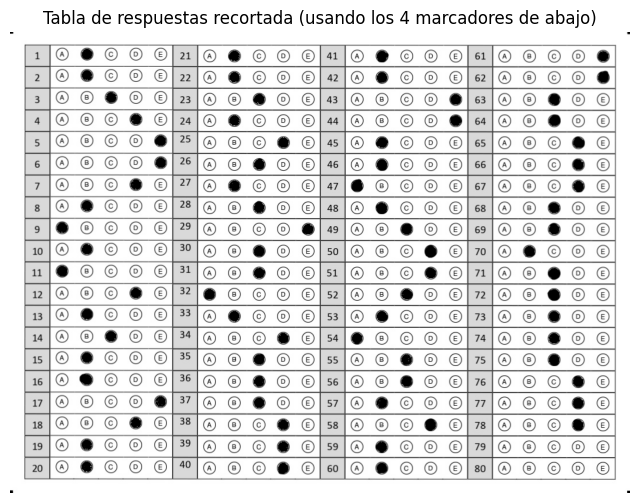

In [7]:
def recortar_tabla_respuestas(image, filas_marcadores, margen_px=5):
    """
    Usa la fila del medio (justo antes de 'Respuestas') y la fila de abajo
    (cerca de 'Duracion del examen') como los 4 puntos que encierran la tabla,
    calcula el perimetro/rectangulo delimitado por ellos y recorta esa zona.
    """
    fila_medio = filas_marcadores[1]
    fila_abajo = filas_marcadores[2]

    puntos = fila_medio + fila_abajo

    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]

    x_left = int(min(xs)) + margen_px
    x_right = int(max(xs)) - margen_px
    y_top = int(min(p[1] for p in fila_medio)) + margen_px
    y_bottom = int(max(p[1] for p in fila_abajo)) - margen_px

    return image[y_top:y_bottom, x_left:x_right]


zona_respuestas = recortar_tabla_respuestas(img_corregida, filas_marcadores_corr)
print(f'Tamaño zona de respuestas: {zona_respuestas.shape}')
mostrar(zona_respuestas, 'Tabla de respuestas recortada (usando los 4 marcadores de abajo)')


## 5. Transformada de Hough — Detección de círculos

Se aplica `cv2.HoughCircles` sobre la zona de respuestas para detectar
todos los círculos (burbujas A B C D E de cada pregunta).

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `dp` | 1 | Resolución acumulador = imagen |
| `minDist` | 20 | Distancia mínima entre centros |
| `param1` | 40 | Umbral Canny interno |
| `param2` | 14 | Mínimo de votos para confirmar círculo |
| `minRadius` | 8 | Radio mínimo de burbuja |
| `maxRadius` | 15 | Radio máximo de burbuja |


Circulos detectados en toda la zona: 400 (esperado: 80 preguntas x 5 = 400)


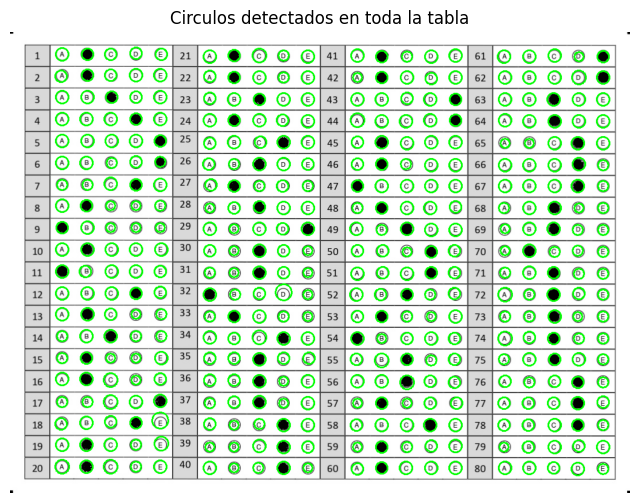

In [8]:
def detectar_circulos_zona_completa(image, dp=1, min_dist=20, param1=40, param2=14,
                                     min_radio=8, max_radio=15):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.medianBlur(gray, 5)

    circulos = cv2.HoughCircles(
        blur, cv2.HOUGH_GRADIENT, dp=dp, minDist=min_dist,
        param1=param1, param2=param2, minRadius=min_radio, maxRadius=max_radio
    )

    if circulos is None:
        return np.array([])
    return np.round(circulos[0, :]).astype(int)


circulos_todos = detectar_circulos_zona_completa(zona_respuestas)
print(f'Circulos detectados en toda la zona: {len(circulos_todos)} (esperado: 80 preguntas x 5 = 400)')

vis = zona_respuestas.copy()
for (x, y, r) in circulos_todos:
    cv2.circle(vis, (x, y), r, (0, 255, 0), 2)
mostrar(vis, 'Circulos detectados en toda la tabla')


## 6. Agrupamiento de círculos por columna (K-Means)

Los círculos detectados se agrupan en **4 columnas** (una por bloque de 20 preguntas)
usando K-Means sobre la coordenada X. Dentro de cada columna se organiza
una grilla de 20 filas × 5 opciones.


Columna 1 (preguntas 1-20): 100 circulos
Columna 2 (preguntas 21-40): 100 circulos
Columna 3 (preguntas 41-60): 100 circulos
Columna 4 (preguntas 61-80): 100 circulos


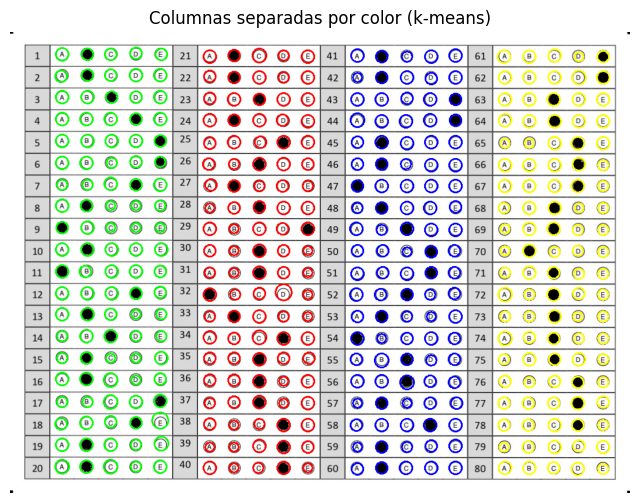

In [9]:
from sklearn.cluster import KMeans

def agrupar_por_columnas(circulos, n_columnas=4):
    """
    Agrupa los circulos en columnas segun su coordenada X, usando k-means.
    Devuelve una lista de arrays de circulos, uno por columna, ordenados de izq. a der.
    """
    xs = circulos[:, 0].reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_columnas, random_state=0, n_init=10).fit(xs)
    etiquetas = kmeans.labels_

    centros = kmeans.cluster_centers_.flatten()
    orden_clusters = np.argsort(centros)

    columnas_circulos = []
    for cluster_id in orden_clusters:
        columnas_circulos.append(circulos[etiquetas == cluster_id])

    return columnas_circulos


def organizar_circulos_en_grilla(circulos, n_filas=20, n_opciones=5):
    """Ordena los circulos de una columna en una grilla de n_filas x n_opciones."""
    if len(circulos) == 0:
        return None
    circulos_ordenados_y = circulos[np.argsort(circulos[:, 1])]
    if len(circulos_ordenados_y) < n_filas * n_opciones:
        return None
    filas = np.array_split(circulos_ordenados_y, n_filas)
    grilla = [fila[np.argsort(fila[:, 0])] for fila in filas]
    return grilla


columnas_circulos = agrupar_por_columnas(circulos_todos, n_columnas=4)

for i, col in enumerate(columnas_circulos):
    print(f'Columna {i+1} (preguntas {i*20+1}-{i*20+20}): {len(col)} circulos')

vis = zona_respuestas.copy()
colores = [(0,255,0), (0,0,255), (255,0,0), (0,255,255)]
for i, col in enumerate(columnas_circulos):
    for (x, y, r) in col:
        cv2.circle(vis, (x, y), r, colores[i], 2)
mostrar(vis, 'Columnas separadas por color (k-means)')


## 7. Conteo de píxeles y Momentos de imagen

Para cada burbuja se aplica una **máscara circular** y se analiza la región con:

- **`cv2.moments`** → calcula el área de píxeles marcados (`m00`)
- La proporción de relleno = `area_marcada / area_mascara`

Se usan **dos criterios** para decidir si una burbuja está marcada:
1. La proporción debe superar un umbral absoluto mínimo (`umbral_absoluto`)
2. La opción ganadora debe superar a la segunda por un margen relativo (`margen_relativo`),
   evitando marcar cuando hay doble marca o ambigüedad


In [10]:
OPCIONES = ['A', 'B', 'C', 'D', 'E']

def proporcion_relleno(gray_img, x, y, r, margen=0.7):
    """
    Calcula la proporcion de pixeles oscuros (marcados) dentro de un circulo,
    usando momentos (cv2.moments -> M00 = area de pixeles encendidos).
    """
    r_interno = int(r * margen)
    mascara = np.zeros(gray_img.shape, dtype='uint8')
    cv2.circle(mascara, (x, y), r_interno, 255, -1)

    region = cv2.bitwise_and(gray_img, gray_img, mask=mascara)
    _, binaria = cv2.threshold(region, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    binaria = cv2.bitwise_and(binaria, mascara)

    momentos_region = cv2.moments(binaria, binaryImage=True)
    momentos_mascara = cv2.moments(mascara, binaryImage=True)

    area_region = momentos_region['m00']
    area_mascara = momentos_mascara['m00']

    if area_mascara == 0:
        return 0.0
    return area_region / area_mascara


## 8. Detección de respuestas marcadas

Se recorre cada pregunta (fila de la grilla) y se determina
cuál opción fue marcada usando los criterios de proporción de relleno.


In [11]:
def calificar_columna(columna_img, grilla, umbral_absoluto=0.15, margen_relativo=1.3):
    """
    Determina la opcion marcada usando dos criterios:
    1. La proporcion de relleno debe superar un umbral absoluto minimo.
    2. La opcion con mayor relleno debe superar a la segunda por un margen relativo.
    """
    gray = cv2.cvtColor(columna_img, cv2.COLOR_BGR2GRAY)
    resultados = []

    for fila in grilla:
        proporciones = [proporcion_relleno(gray, x, y, r) for (x, y, r) in fila[:len(OPCIONES)]]

        if len(proporciones) < len(OPCIONES):
            resultados.append(None)
            continue

        ordenadas = sorted(proporciones, reverse=True)
        mayor, segunda = ordenadas[0], ordenadas[1]

        idx_max = int(np.argmax(proporciones))

        if mayor < umbral_absoluto:
            resultados.append(None)
        elif segunda > 0 and (mayor / segunda) < margen_relativo:
            resultados.append(None)
        else:
            resultados.append(OPCIONES[idx_max])

    return resultados


respuestas_alumno = {}

for i, col_circulos in enumerate(columnas_circulos):
    grilla = organizar_circulos_en_grilla(col_circulos, n_filas=20, n_opciones=5)
    if grilla is None:
        print(f'Columna {i+1}: no se pudo armar la grilla 20x5, revisar.')
        continue

    respuestas_columna = calificar_columna(zona_respuestas, grilla)
    pregunta_inicial = i * 20 + 1
    for j, respuesta in enumerate(respuestas_columna):
        respuestas_alumno[pregunta_inicial + j] = respuesta

print('--- Respuestas detectadas ---')
for pregunta in sorted(respuestas_alumno.keys()):
    print(f'Pregunta {pregunta:2d}: {respuestas_alumno[pregunta]}')


--- Respuestas detectadas ---
Pregunta  1: B
Pregunta  2: B
Pregunta  3: C
Pregunta  4: D
Pregunta  5: E
Pregunta  6: E
Pregunta  7: D
Pregunta  8: B
Pregunta  9: A
Pregunta 10: B
Pregunta 11: A
Pregunta 12: D
Pregunta 13: B
Pregunta 14: C
Pregunta 15: B
Pregunta 16: B
Pregunta 17: E
Pregunta 18: D
Pregunta 19: B
Pregunta 20: B
Pregunta 21: B
Pregunta 22: B
Pregunta 23: C
Pregunta 24: B
Pregunta 25: D
Pregunta 26: C
Pregunta 27: B
Pregunta 28: C
Pregunta 29: E
Pregunta 30: C
Pregunta 31: C
Pregunta 32: A
Pregunta 33: B
Pregunta 34: D
Pregunta 35: C
Pregunta 36: C
Pregunta 37: C
Pregunta 38: D
Pregunta 39: D
Pregunta 40: D
Pregunta 41: B
Pregunta 42: B
Pregunta 43: E
Pregunta 44: E
Pregunta 45: B
Pregunta 46: B
Pregunta 47: A
Pregunta 48: B
Pregunta 49: C
Pregunta 50: D
Pregunta 51: D
Pregunta 52: C
Pregunta 53: B
Pregunta 54: A
Pregunta 55: C
Pregunta 56: C
Pregunta 57: B
Pregunta 58: D
Pregunta 59: B
Pregunta 60: B
Pregunta 61: E
Pregunta 62: E
Pregunta 63: C
Pregunta 64: C
Pregunta 6

## 9. Calificación con clave de respuestas

Se compara cada respuesta detectada con la clave correcta.
**Reemplaza el diccionario `clave_respuestas`** con las respuestas reales de tu examen.


In [12]:
# ⚠️ REEMPLAZA con la clave real de tu examen
clave_respuestas = {i: 'A' for i in range(1, 81)}  # PLACEHOLDER

def calificar_examen(respuestas_alumno, clave_respuestas):
    correctas = 0
    incorrectas = 0
    sin_marcar = 0
    detalle = {}

    for pregunta, clave in clave_respuestas.items():
        respuesta = respuestas_alumno.get(pregunta)
        if respuesta is None:
            sin_marcar += 1
            detalle[pregunta] = 'sin marcar'
        elif respuesta == clave:
            correctas += 1
            detalle[pregunta] = 'correcta'
        else:
            incorrectas += 1
            detalle[pregunta] = f'incorrecta (marco {respuesta}, era {clave})'

    total = len(clave_respuestas)
    nota_vigesimal = round((correctas / total) * 20, 2)

    return {
        'correctas': correctas,
        'incorrectas': incorrectas,
        'sin_marcar': sin_marcar,
        'total': total,
        'nota_vigesimal': nota_vigesimal,
        'detalle': detalle
    }


resultado = calificar_examen(respuestas_alumno, clave_respuestas)

print(f"Correctas:   {resultado['correctas']}")
print(f"Incorrectas: {resultado['incorrectas']}")
print(f"Sin marcar:  {resultado['sin_marcar']}")
print(f"Nota (0-20): {resultado['nota_vigesimal']}")


Correctas:   5
Incorrectas: 73
Sin marcar:  2
Nota (0-20): 1.25


## 10. Resultado final con nota anotada

Se genera la imagen final con:
- 🔴 **Rojo** — burbuja detectada como marcada
- 🟢 **Verde** — burbuja no marcada
- La **nota** escrita sobre la imagen
- El resultado guardado en Google Drive


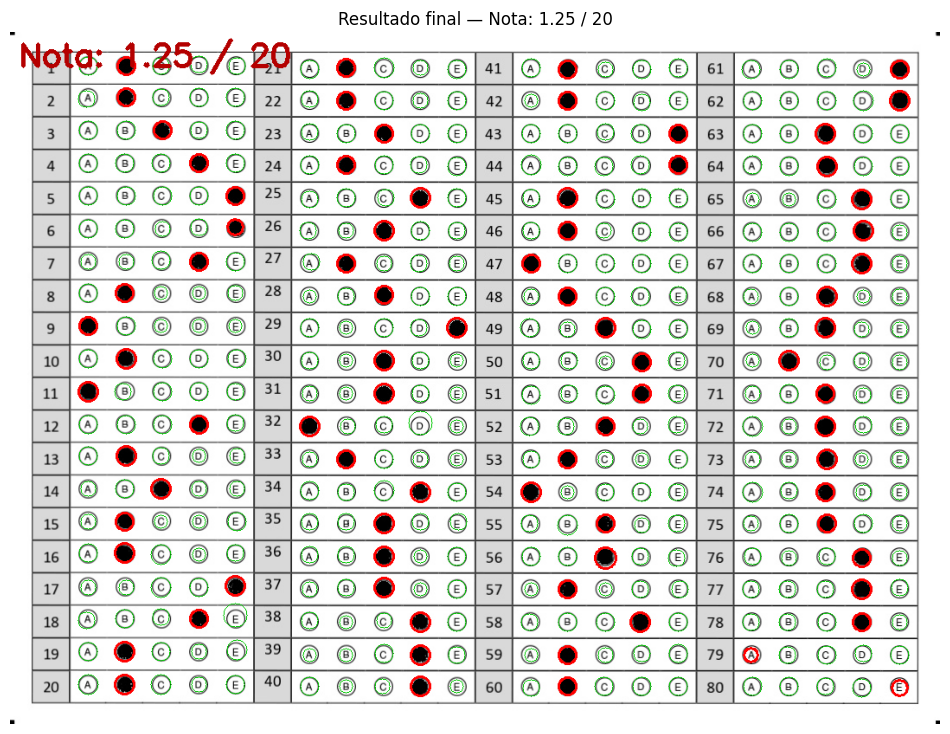

Imagen guardada en: /content/drive/MyDrive/Proyecto_Final/resultado_final.jpg

  CORRECTAS  : 5 / 80
  INCORRECTAS: 73
  SIN MARCAR : 2
  NOTA FINAL : 1.25 / 20


In [13]:
# Imagen final anotada con resultado
img_resultado = zona_respuestas.copy()
gray_zona = cv2.cvtColor(zona_respuestas, cv2.COLOR_BGR2GRAY)

for i, col_circulos in enumerate(columnas_circulos):
    grilla = organizar_circulos_en_grilla(col_circulos, n_filas=20, n_opciones=5)
    if grilla is None:
        continue
    for fila in grilla:
        proporciones = [proporcion_relleno(gray_zona, x, y, r)
                        for (x, y, r) in fila[:len(OPCIONES)]]
        idx_max = int(np.argmax(proporciones))
        for op_idx, (x, y, r) in enumerate(fila[:len(OPCIONES)]):
            if op_idx == idx_max and proporciones[idx_max] >= 0.15:
                cv2.circle(img_resultado, (x, y), r, (0, 0, 255), 2)   # rojo = marcada
            else:
                cv2.circle(img_resultado, (x, y), r, (0, 200, 0), 1)   # verde = no marcada

# Anotar nota en la imagen
nota  = resultado['nota_vigesimal']
texto = f"Nota: {nota} / 20"
cv2.putText(img_resultado, texto,
            (10, 40), cv2.FONT_HERSHEY_SIMPLEX,
            1.2, (0, 0, 180), 3)

# Mostrar imagen final
mostrar(img_resultado, f'Resultado final — Nota: {nota} / 20', figsize=(12, 10))

# Guardar en Drive
RUTA_SALIDA = '/content/drive/MyDrive/Proyecto_Final/resultado_final.jpg'
cv2.imwrite(RUTA_SALIDA, img_resultado)
print(f'Imagen guardada en: {RUTA_SALIDA}')
print()
print('=' * 40)
print(f'  CORRECTAS  : {resultado["correctas"]} / {resultado["total"]}')
print(f'  INCORRECTAS: {resultado["incorrectas"]}')
print(f'  SIN MARCAR : {resultado["sin_marcar"]}')
print(f'  NOTA FINAL : {nota} / 20')
print('=' * 40)
